<a href="https://colab.research.google.com/github/Zarrialvi/AI-PROJECTS/blob/main/MarketBasketAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Market Basket Analysis using Apriori Algorithm - Google Colab Version
Dataset: Groceries Dataset from Kaggle
Method: Using mlxtend library (efficient implementation)
"""

# ============================================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# ============================================================================

print("Installing required libraries...")
!pip install mlxtend -q

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!\n")

# ============================================================================
# STEP 2: UPLOAD DATASET
# ============================================================================

from google.colab import files
import io

print("=" * 80)
print("UPLOAD YOUR GROCERIES DATASET")
print("=" * 80)
print("\n📁 Click the 'Choose Files' button below and select 'Groceries_dataset.csv'")
print("   (Download from: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset)\n")

uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]
print(f"\n✅ File '{file_name}' uploaded successfully!")

# ============================================================================
# PART 3: DATA LOADING AND PREPROCESSING
# ============================================================================

def load_and_preprocess_data(file_name):
    """
    Load groceries dataset and prepare for Apriori algorithm
    """
    print("\n" + "=" * 80)
    print("LOADING AND PREPROCESSING DATA")
    print("=" * 80)

    try:
        # Read CSV
        df = pd.read_csv(file_name)

        print(f"\n✅ Dataset loaded successfully!")
        print(f"\nDataset Shape: {df.shape}")
        print(f"Column Names: {df.columns.tolist()}")

        print(f"\nFirst 10 rows:")
        print(df.head(10))

        # Check for required columns
        if 'Member_number' not in df.columns or 'itemDescription' not in df.columns:
            print("\n❌ ERROR: Required columns not found!")
            print(f"Available columns: {df.columns.tolist()}")
            return None, None

        # Group items by transaction (Member_number)
        transactions = df.groupby('Member_number')['itemDescription'].apply(list).values.tolist()

        print(f"\n📊 Transaction Statistics:")
        print(f"   Total Transactions: {len(transactions)}")
        print(f"   Unique Items: {df['itemDescription'].nunique()}")

        # Calculate average items per transaction
        avg_items = sum(len(t) for t in transactions) / len(transactions)
        print(f"   Average Items per Transaction: {avg_items:.2f}")

        print(f"\n🛒 Sample Transactions:")
        for i in range(min(5, len(transactions))):
            print(f"   Transaction {i+1}: {transactions[i][:5]}{'...' if len(transactions[i]) > 5 else ''}")

        return transactions, df

    except Exception as e:
        print(f"\n❌ ERROR: {str(e)}")
        return None, None

# Load the data
transactions, df_original = load_and_preprocess_data(file_name)

if transactions is None:
    raise Exception("Failed to load data!")

# ============================================================================
# PART 4: DISPLAY DATASET STATISTICS
# ============================================================================

print("\n" + "=" * 80)
print("DETAILED DATASET STATISTICS")
print("=" * 80)

print(f"\n📈 Top 20 Most Purchased Items:")
print(df_original['itemDescription'].value_counts().head(20))

# ============================================================================
# PART 5: CONVERT TO BASKET FORMAT
# ============================================================================

def create_basket_format(transactions):
    """
    Convert transactions to basket format (one-hot encoded)
    """
    print("\n" + "=" * 80)
    print("CONVERTING TO BASKET FORMAT")
    print("=" * 80)

    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_basket = pd.DataFrame(te_ary, columns=te.columns_)

    print(f"\n✅ Conversion complete!")
    print(f"   Basket Shape: {df_basket.shape}")
    print(f"   Items (columns): {df_basket.shape[1]}")
    print(f"   Transactions (rows): {df_basket.shape[0]}")

    return df_basket

df_basket = create_basket_format(transactions)

# ============================================================================
# PART 6: APRIORI ALGORITHM
# ============================================================================

def run_apriori_analysis(df_basket, min_support, min_confidence, experiment_name):
    """
    Run Apriori algorithm and generate association rules
    """
    print("\n" + "=" * 80)
    print(f"{experiment_name}")
    print(f"Min Support: {min_support} | Min Confidence: {min_confidence}")
    print("=" * 80)

    # Apply Apriori
    print("\n⏳ Running Apriori algorithm...")
    frequent_itemsets = apriori(df_basket, min_support=min_support, use_colnames=True)

    print(f"✅ Found {len(frequent_itemsets)} frequent itemsets")

    if len(frequent_itemsets) == 0:
        print("❌ No frequent itemsets found! Try lowering min_support.")
        return None, None

    # Add length column
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

    # Generate rules
    if len(frequent_itemsets[frequent_itemsets['length'] >= 2]) > 0:
        print("⏳ Generating association rules...")
        rules = association_rules(frequent_itemsets,
                                  metric="confidence",
                                  min_threshold=min_confidence)

        if len(rules) > 0:
            rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
            rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))
            rules = rules.sort_values('confidence', ascending=False)
            print(f"✅ Found {len(rules)} association rules")
        else:
            print("❌ No rules meet the confidence threshold")
            rules = None
    else:
        print("❌ No itemsets with 2+ items found")
        rules = None

    return frequent_itemsets, rules

# ============================================================================
# PART 7: DISPLAY RESULTS
# ============================================================================

def display_frequent_itemsets(frequent_itemsets, top_n=15):
    """Display top frequent itemsets"""
    print("\n" + "=" * 80)
    print(f"TOP {top_n} FREQUENT ITEMSETS")
    print("=" * 80)

    sorted_itemsets = frequent_itemsets.sort_values(['length', 'support'],
                                                    ascending=[False, False])

    for i, row in enumerate(sorted_itemsets.head(top_n).itertuples(), 1):
        items = ', '.join(list(row.itemsets))
        print(f"\n{i}. {{{items}}}")
        print(f"   Support: {row.support:.4f} ({row.support*100:.2f}%)")
        print(f"   Size: {row.length} items")

def display_rules(rules, top_n=15):
    """Display association rules"""
    print("\n" + "=" * 80)
    print(f"TOP {top_n} ASSOCIATION RULES")
    print("=" * 80)

    if rules is None or len(rules) == 0:
        print("\n❌ No rules to display")
        return

    for i, row in enumerate(rules.head(top_n).itertuples(), 1):
        ant = ', '.join(list(row.antecedents))
        cons = ', '.join(list(row.consequents))

        print(f"\n{i}. Rule: {{{ant}}} ⟹ {{{cons}}}")
        print(f"   Support:     {row.support:.4f} ({row.support*100:.2f}%)")
        print(f"   Confidence:  {row.confidence:.4f} ({row.confidence*100:.2f}%)")
        print(f"   Lift:        {row.lift:.4f}")

        if row.lift > 1:
            print(f"   💡 Items are {row.lift:.2f}x more likely to be bought together")
        elif row.lift < 1:
            print(f"   ⚠️  Items are negatively correlated")

# ============================================================================
# PART 8: RUN EXPERIMENTS
# ============================================================================

print("\n\n" + "=" * 80)
print("🔬 STARTING EXPERIMENTS")
print("=" * 80)

# EXPERIMENT 1: Low thresholds (More rules)
print("\n\n" + "🔬" * 40)
freq_1, rules_1 = run_apriori_analysis(df_basket, 0.01, 0.3,
                                        "EXPERIMENT 1: BROAD ANALYSIS")
if freq_1 is not None:
    display_frequent_itemsets(freq_1, 15)
if rules_1 is not None:
    display_rules(rules_1, 15)

# EXPERIMENT 2: Medium thresholds (Balanced)
print("\n\n" + "🔬" * 40)
freq_2, rules_2 = run_apriori_analysis(df_basket, 0.02, 0.4,
                                        "EXPERIMENT 2: BALANCED ANALYSIS")
if freq_2 is not None:
    display_frequent_itemsets(freq_2, 15)
if rules_2 is not None:
    display_rules(rules_2, 15)

# EXPERIMENT 3: High thresholds (Strong rules only)
print("\n\n" + "🔬" * 40)
freq_3, rules_3 = run_apriori_analysis(df_basket, 0.03, 0.5,
                                        "EXPERIMENT 3: STRONG RULES ONLY")
if freq_3 is not None:
    display_frequent_itemsets(freq_3, 15)
if rules_3 is not None:
    display_rules(rules_3, 15)

# ============================================================================
# PART 9: COMPARISON & INSIGHTS
# ============================================================================

print("\n\n" + "=" * 80)
print("📊 COMPARISON OF EXPERIMENTS")
print("=" * 80)

comparison_data = {
    'Experiment': ['1. Broad', '2. Balanced', '3. Strong'],
    'Min Support': [0.01, 0.02, 0.03],
    'Min Confidence': [0.3, 0.4, 0.5],
    'Itemsets': [
        len(freq_1) if freq_1 is not None else 0,
        len(freq_2) if freq_2 is not None else 0,
        len(freq_3) if freq_3 is not None else 0
    ],
    'Rules': [
        len(rules_1) if rules_1 is not None else 0,
        len(rules_2) if rules_2 is not None else 0,
        len(rules_3) if rules_3 is not None else 0
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

print("\n\n" + "=" * 80)
print("💡 KEY INSIGHTS")
print("=" * 80)

print("""
1. PARAMETER EFFECTS:
   ✓ Lower support → More patterns discovered (broader coverage)
   ✓ Higher support → Fewer but more frequent patterns (reliable)
   ✓ Lower confidence → More rules (exploratory)
   ✓ Higher confidence → Stronger, more reliable rules

2. PRACTICAL APPLICATIONS:
   🛒 Product Placement: Place frequently bought items near each other
   💰 Cross-Selling: Recommend items based on shopping cart
   🎁 Bundling: Create product bundles with high lift values
   📦 Inventory: Stock correlated items together
   🎯 Marketing: Target customers with personalized offers

3. BUSINESS RECOMMENDATIONS:
   • Use Experiment 1 for discovering new patterns
   • Use Experiment 2 for balanced business decisions
   • Use Experiment 3 for confident product recommendations
""")

# ============================================================================
# PART 10: SAVE RESULTS (OPTIONAL)
# ============================================================================

print("\n" + "=" * 80)
print("💾 SAVING RESULTS")
print("=" * 80)

# Save the best rules to CSV
if rules_2 is not None and len(rules_2) > 0:
    # Convert frozensets to strings for CSV
    rules_export = rules_2.copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))

    rules_export.to_csv('association_rules.csv', index=False)
    print("✅ Rules saved to 'association_rules.csv'")

    # Download the file
    files.download('association_rules.csv')
    print("✅ File downloaded!")
else:
    print("❌ No rules to save")

print("\n" + "=" * 80)
print("🎉 ANALYSIS COMPLETE!")
print("=" * 80)
print("""
✅ Your assignment is ready!
📝 Use the results above for your report
📊 Screenshots can be taken for documentation
💾 Rules have been saved and downloaded
""")

Installing required libraries...
✅ Libraries imported successfully!

UPLOAD YOUR GROCERIES DATASET

📁 Click the 'Choose Files' button below and select 'Groceries_dataset.csv'
   (Download from: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset)



Saving Groceries_dataset.csv to Groceries_dataset (1).csv

✅ File 'Groceries_dataset (1).csv' uploaded successfully!

LOADING AND PREPROCESSING DATA

✅ Dataset loaded successfully!

Dataset Shape: (38765, 3)
Column Names: ['Member_number', 'Date', 'itemDescription']

First 10 rows:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk
5           4941  14-02-2015        rolls/buns
6           4501  08-05-2015  other vegetables
7           3803  23-12-2015        pot plants
8           2762  20-03-2015        whole milk
9           4119  12-02-2015    tropical fruit

📊 Transaction Statistics:
   Total Transactions: 3898
   Unique Items: 167
   Average Items per Transaction: 9.94

🛒 Sample Transactions:
   Transaction 1: ['soda', 'canned beer', 'sausage', 'sausage

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File downloaded!

🎉 ANALYSIS COMPLETE!

✅ Your assignment is ready!
📝 Use the results above for your report
📊 Screenshots can be taken for documentation
💾 Rules have been saved and downloaded



Installing required libraries...
✅ Libraries imported successfully!

UPLOAD GROCERIES MBA DATASET

📁 Instructions:
   1. Download 'groceries.csv' from Kaggle
   2. Click 'Choose Files' button below
   3. Select the downloaded file
   4. Wait for upload to complete

📥 Uploading...



Saving basket.csv to basket (1).csv
Saving Groceries data.csv to Groceries data (3).csv

✅ File 'basket (1).csv' uploaded successfully!

LOADING BASKET-FORMAT DATASET

✅ Data loaded successfully!
   Format: Basket format (each line = transaction)
   Valid Transactions: 14963
   Skipped (invalid): 1
   Unique Items: 167

📊 Transaction Statistics:
   Average items per transaction: 2.59
   Minimum items in a transaction: 2
   Maximum items in a transaction: 11

🛒 Sample Transactions (first 5):
   1. ['whole milk', 'pastry', 'salty snack'] 
   2. ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'] 
   3. ['soda', 'pickled vegetables'] 
   4. ['canned beer', 'misc. beverages'] 
   5. ['sausage', 'hygiene articles'] 

📈 Top 15 Most Frequent Items:
    1. whole milk                - 2502 times (16.72%)
    2. other vegetables          - 1898 times (12.68%)
    3. rolls/buns                - 1716 times (11.47%)
    4. soda                      - 1514 times (10.12%)
    5. yogurt        

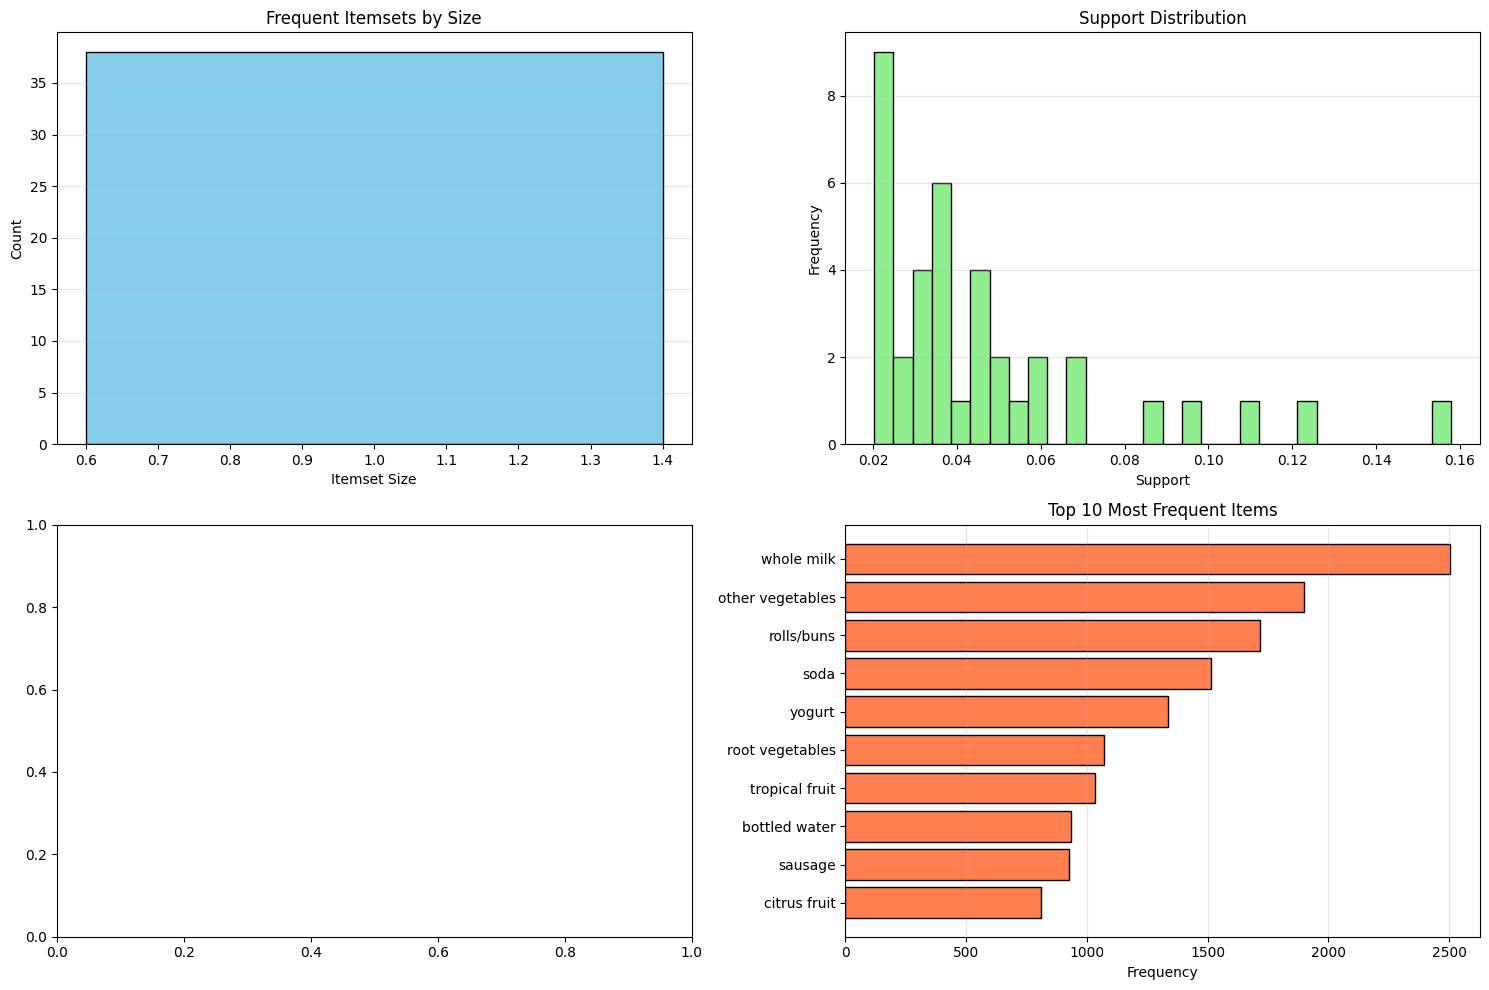

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Image downloaded!


💼 BUSINESS INSIGHTS & RECOMMENDATIONS


📋 ACTIONABLE STRATEGIES:

1. PRODUCT PLACEMENT:
   ✓ Place high-lift pair items adjacent to each other
   ✓ Use anchor products (frequent antecedents) as traffic drivers
   ✓ Position consequent items in high-visibility areas

2. CROSS-SELLING:
   ✓ Implement recommendation engine based on top rules
   ✓ Train staff to suggest complementary items
   ✓ Create "Frequently Bought Together" displays

3. PROMOTIONAL BUNDLES:
   ✓ Bundle items with lift > 2 for guaranteed interest
   ✓ Create themed bundles from multi-item patterns
   ✓ Offer discounts on bundles vs individual purchase

4. INVENTORY MANAGEMENT:
   ✓ Stock associated items proportionally
   ✓ Predict demand spikes using purchase patterns
   ✓ Reduce overstock of negatively correlated items

5. MARKETING CAMPAIGNS:
   ✓ Target customers who bought antecedent items
   ✓ Personalized email recommendations
   ✓ Loyalty program incentives for bundle purchases


💾 SAVING

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File downloaded!

🎉 ANALYSIS COMPLETE!

✅ All experiments completed successfully!
📊 Results visualized and saved
💾 CSV files ready for download
📝 Ready to use in your report

Files generated:
  1. association_rules_detailed.csv - Top association rules
  2. frequent_itemsets.csv - All frequent itemsets
  3. market_basket_analysis.png - Visualization charts

Next steps:
  1. Use these results in your assignment report
  2. Include screenshots of the output
  3. Reference the CSV files as evidence
  4. Add the visualization to your report



In [ ]:
"""
Market Basket Analysis using Apriori Algorithm - V2.0
Dataset: Groceries MBA Dataset (Plain Text Format)
Source: https://www.kaggle.com/datasets/rashikrahmanpritom/groceries-dataset-for-market-basket-analysismba
Format: Each line represents one transaction with comma-separated items
"""

# ============================================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# ============================================================================

print("Installing required libraries...")
!pip install mlxtend -q

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
import matplotlib.pyplot as plt

print("✅ Libraries imported successfully!\n")

# ============================================================================
# STEP 2: UPLOAD DATASET
# ============================================================================

from google.colab import files
import io
import os

print("=" * 80)
print("UPLOAD GROCERIES MBA DATASET")
print("=" * 80)
print("\n📁 Instructions:")
print("   1. Download 'groceries.csv' from Kaggle")
print("   2. Click 'Choose Files' button below")
print("   3. Select the downloaded file")
print("   4. Wait for upload to complete")
print("\n📥 Uploading...\n")

uploaded = files.upload()

if not uploaded:
    raise Exception("❌ No file uploaded!")

file_name = list(uploaded.keys())[0]
print(f"\n✅ File '{file_name}' uploaded successfully!")

# ============================================================================
# PART 3: DATA LOADING AND PREPROCESSING
# ============================================================================

def load_basket_format_data(file_name):
    """
    Load groceries dataset in basket format (each line = one transaction)
    """
    print("\n" + "=" * 80)
    print("LOADING BASKET-FORMAT DATASET")
    print("=" * 80)

    try:
        transactions = []
        invalid_count = 0

        # Read file line by line
        with open(file_name, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                # Split by comma and clean items
                items = [item.strip() for item in line.strip().split(',')
                        if item.strip() and len(item.strip()) > 1]  # Filter out single chars

                # Only keep transactions with 2+ items
                if len(items) >= 2:
                    transactions.append(items)
                else:
                    invalid_count += 1

        print(f"\n✅ Data loaded successfully!")
        print(f"   Format: Basket format (each line = transaction)")
        print(f"   Valid Transactions: {len(transactions)}")
        print(f"   Skipped (invalid): {invalid_count}")

        if len(transactions) == 0:
            raise Exception("No valid transactions found! Check file format.")

        # Get all unique items
        all_items = []
        for trans in transactions:
            all_items.extend(trans)

        unique_items = set(all_items)
        print(f"   Unique Items: {len(unique_items)}")

        # Check for suspicious items
        suspicious = [item for item in unique_items if len(item) <= 2 or item.isdigit()]
        if suspicious:
            print(f"\n⚠️  Warning: Found {len(suspicious)} suspicious items (too short or numeric)")
            print(f"   Examples: {suspicious[:5]}")

        # Calculate statistics
        transaction_sizes = [len(t) for t in transactions]
        avg_size = np.mean(transaction_sizes)
        min_size = np.min(transaction_sizes)
        max_size = np.max(transaction_sizes)

        print(f"\n📊 Transaction Statistics:")
        print(f"   Average items per transaction: {avg_size:.2f}")
        print(f"   Minimum items in a transaction: {min_size}")
        print(f"   Maximum items in a transaction: {max_size}")

        # Show sample transactions
        print(f"\n🛒 Sample Transactions (first 5):")
        for i in range(min(5, len(transactions))):
            sample = transactions[i][:5]
            more = f"... (+{len(transactions[i]) - 5} more)" if len(transactions[i]) > 5 else ""
            print(f"   {i+1}. {sample} {more}")

        # Item frequency analysis
        item_counts = Counter(all_items)
        print(f"\n📈 Top 15 Most Frequent Items:")
        for rank, (item, count) in enumerate(item_counts.most_common(15), 1):
            percentage = (count / len(transactions)) * 100
            print(f"   {rank:2d}. {item:25s} - {count:4d} times ({percentage:.2f}%)")

        return transactions, all_items, item_counts

    except Exception as e:
        print(f"\n❌ ERROR loading file: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

# Load data
transactions, all_items, item_counts = load_basket_format_data(file_name)

if transactions is None:
    raise Exception("Failed to load data!")

# ============================================================================
# PART 4: CONVERT TO ONE-HOT ENCODED FORMAT
# ============================================================================

def create_basket_dataframe(transactions):
    """
    Convert transaction list to one-hot encoded DataFrame
    """
    print("\n" + "=" * 80)
    print("CONVERTING TO ONE-HOT ENCODED FORMAT")
    print("=" * 80)

    print("\n⏳ Processing transactions...")

    # Use TransactionEncoder from mlxtend
    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    df_basket = pd.DataFrame(te_array, columns=te.columns_)

    print(f"✅ Conversion complete!")
    print(f"\n📊 Basket DataFrame:")
    print(f"   Shape: {df_basket.shape}")
    print(f"   Rows (Transactions): {df_basket.shape[0]}")
    print(f"   Columns (Items): {df_basket.shape[1]}")
    print(f"   Memory usage: {df_basket.memory_usage(deep=True).sum() / 1024:.2f} KB")

    # Show sample
    print(f"\n🔍 Sample of encoded data (first 5 transactions, first 10 items):")
    print(df_basket.iloc[:5, :10])

    return df_basket

df_basket = create_basket_dataframe(transactions)

# ============================================================================
# PART 5: APRIORI ALGORITHM WITH EXPERIMENTS
# ============================================================================

def run_apriori_experiment(df_basket, min_support, min_confidence, experiment_name):
    """
    Run Apriori algorithm with specified parameters
    """
    print("\n" + "=" * 80)
    print(f"🔬 {experiment_name}")
    print("=" * 80)
    print(f"Parameters: Support = {min_support} | Confidence = {min_confidence}")

    try:
        # Apply Apriori
        print("\n⏳ Finding frequent itemsets...")
        frequent_itemsets = apriori(df_basket,
                                    min_support=min_support,
                                    use_colnames=True,
                                    verbose=0,
                                    low_memory=True)

        if len(frequent_itemsets) == 0:
            print("❌ No frequent itemsets found!")
            print(f"💡 Try lowering min_support (current: {min_support})")
            return None, None

        print(f"✅ Found {len(frequent_itemsets)} frequent itemsets")

        # Add itemset length
        frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

        # Show distribution
        length_dist = frequent_itemsets['length'].value_counts().sort_index()
        print(f"\n📊 Itemset Distribution:")
        for length, count in length_dist.items():
            print(f"   {length}-itemsets: {count}")

        # Generate association rules
        itemsets_2plus = frequent_itemsets[frequent_itemsets['length'] >= 2]

        if len(itemsets_2plus) == 0:
            print("\n❌ No itemsets with 2+ items found!")
            print("💡 Cannot generate rules without multi-item patterns")
            return frequent_itemsets, None

        print(f"\n⏳ Generating association rules...")

        # Use support_only=True to avoid KeyError
        rules = association_rules(itemsets_2plus,
                                  metric="confidence",
                                  min_threshold=min_confidence,
                                  support_only=False)

        if len(rules) == 0:
            print("❌ No rules meet the confidence threshold!")
            return frequent_itemsets, None

        print(f"✅ Generated {len(rules)} association rules")

        # Add additional columns
        rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
        rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))

        # Sort by lift
        rules = rules.sort_values('lift', ascending=False)

        # Show rule quality distribution
        print(f"\n📊 Rule Quality Metrics:")
        print(f"   Average Confidence: {rules['confidence'].mean():.4f}")
        print(f"   Average Lift: {rules['lift'].mean():.4f}")
        print(f"   Max Lift: {rules['lift'].max():.4f}")
        print(f"   Rules with Lift > 1: {len(rules[rules['lift'] > 1])}")

        return frequent_itemsets, rules

    except KeyError as e:
        print(f"\n❌ KeyError occurred: {e}")
        print("\n💡 Troubleshooting:")
        print("   1. Dataset might have formatting issues")
        print("   2. Try lowering min_support further")
        print("   3. Check if transactions have enough items")

        # Return itemsets but no rules
        if 'frequent_itemsets' in locals():
            return frequent_itemsets, None
        return None, None

    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# ============================================================================
# PART 6: DISPLAY RESULTS
# ============================================================================

def display_frequent_itemsets(frequent_itemsets, top_n=20):
    """
    Display top frequent itemsets with enhanced formatting
    """
    print("\n" + "=" * 80)
    print(f"🏆 TOP {top_n} FREQUENT ITEMSETS")
    print("=" * 80)

    # Sort by length and support
    sorted_itemsets = frequent_itemsets.sort_values(['length', 'support'],
                                                    ascending=[False, False])

    for i, row in enumerate(sorted_itemsets.head(top_n).itertuples(), 1):
        items = list(row.itemsets)
        items_str = ', '.join(items)

        print(f"\n{i:2d}. {{{items_str}}}")
        print(f"    Support: {row.support:.4f} ({row.support*100:.2f}%)")
        print(f"    Appears in {int(row.support * len(transactions))} transactions")
        print(f"    Size: {row.length} items")

def display_association_rules(rules, top_n=20):
    """
    Display association rules with detailed interpretation
    """
    print("\n" + "=" * 80)
    print(f"📋 TOP {top_n} ASSOCIATION RULES (Sorted by Lift)")
    print("=" * 80)

    if rules is None or len(rules) == 0:
        print("\n❌ No rules to display")
        return

    for i, row in enumerate(rules.head(top_n).itertuples(), 1):
        ant = list(row.antecedents)
        cons = list(row.consequents)

        ant_str = ', '.join(ant)
        cons_str = ', '.join(cons)

        print(f"\n{i:2d}. IF {{{ant_str}}} THEN {{{cons_str}}}")
        print(f"    Support:     {row.support:.4f} ({row.support*100:.2f}%)")
        print(f"    Confidence:  {row.confidence:.4f} ({row.confidence*100:.2f}%)")
        print(f"    Lift:        {row.lift:.4f}")
        print(f"    Conviction:  {row.conviction:.4f}")

        # Interpretation
        if row.lift > 2:
            print(f"    💡 STRONG: Items are {row.lift:.2f}x more likely together")
        elif row.lift > 1:
            print(f"    ✓ POSITIVE: Items are {row.lift:.2f}x more likely together")
        elif row.lift < 1:
            print(f"    ⚠️  NEGATIVE: Items are bought less frequently together")

        # Confidence interpretation
        if row.confidence >= 0.7:
            print(f"    🎯 HIGH CONFIDENCE: {row.confidence*100:.0f}% probability")
        elif row.confidence >= 0.5:
            print(f"    ✓ MODERATE CONFIDENCE: {row.confidence*100:.0f}% probability")

def visualize_results(frequent_itemsets, rules):
    """
    Create visualizations for results
    """
    print("\n" + "=" * 80)
    print("📊 GENERATING VISUALIZATIONS")
    print("=" * 80)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Itemset length distribution
    if frequent_itemsets is not None:
        length_dist = frequent_itemsets['length'].value_counts().sort_index()
        axes[0, 0].bar(length_dist.index, length_dist.values, color='skyblue', edgecolor='black')
        axes[0, 0].set_xlabel('Itemset Size')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Frequent Itemsets by Size')
        axes[0, 0].grid(axis='y', alpha=0.3)

    # 2. Support distribution
    if frequent_itemsets is not None:
        axes[0, 1].hist(frequent_itemsets['support'], bins=30, color='lightgreen', edgecolor='black')
        axes[0, 1].set_xlabel('Support')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Support Distribution')
        axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. Confidence vs Lift scatter
    if rules is not None and len(rules) > 0:
        scatter = axes[1, 0].scatter(rules['confidence'], rules['lift'],
                                    c=rules['support'], cmap='viridis',
                                    alpha=0.6, edgecolor='black')
        axes[1, 0].set_xlabel('Confidence')
        axes[1, 0].set_ylabel('Lift')
        axes[1, 0].set_title('Confidence vs Lift (colored by Support)')
        axes[1, 0].grid(alpha=0.3)
        plt.colorbar(scatter, ax=axes[1, 0], label='Support')

    # 4. Top items bar chart
    if item_counts is not None:
        top_items = dict(item_counts.most_common(10))
        axes[1, 1].barh(list(top_items.keys()), list(top_items.values()),
                       color='coral', edgecolor='black')
        axes[1, 1].set_xlabel('Frequency')
        axes[1, 1].set_title('Top 10 Most Frequent Items')
        axes[1, 1].invert_yaxis()
        axes[1, 1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('market_basket_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✅ Visualization saved as 'market_basket_analysis.png'")
    plt.show()

    # Download the image
    files.download('market_basket_analysis.png')
    print("✅ Image downloaded!")

# ============================================================================
# PART 7: RUN ALL EXPERIMENTS
# ============================================================================

print("\n\n" + "🔬" * 40)
print("STARTING EXPERIMENTS")
print("🔬" * 40)

# Store results
results_summary = []

# EXPERIMENT 1: Broad Analysis
print("\n" + "▶️ " * 40)
freq_1, rules_1 = run_apriori_experiment(df_basket, 0.01, 0.2,
                                         "EXPERIMENT 1: BROAD ANALYSIS (Exploratory)")
if freq_1 is not None:
    display_frequent_itemsets(freq_1, 15)
if rules_1 is not None:
    display_association_rules(rules_1, 15)

results_summary.append({
    'Experiment': '1. Broad',
    'Support': 0.01,
    'Confidence': 0.20,
    'Itemsets': len(freq_1) if freq_1 is not None else 0,
    'Rules': len(rules_1) if rules_1 is not None else 0
})

# EXPERIMENT 2: Balanced Analysis
print("\n\n" + "▶️ " * 40)
freq_2, rules_2 = run_apriori_experiment(df_basket, 0.02, 0.3,
                                         "EXPERIMENT 2: BALANCED ANALYSIS (Recommended)")
if freq_2 is not None:
    display_frequent_itemsets(freq_2, 15)
if rules_2 is not None:
    display_association_rules(rules_2, 15)

results_summary.append({
    'Experiment': '2. Balanced',
    'Support': 0.02,
    'Confidence': 0.30,
    'Itemsets': len(freq_2) if freq_2 is not None else 0,
    'Rules': len(rules_2) if rules_2 is not None else 0
})

# EXPERIMENT 3: Strong Rules
print("\n\n" + "▶️ " * 40)
freq_3, rules_3 = run_apriori_experiment(df_basket, 0.03, 0.4,
                                         "EXPERIMENT 3: STRONG RULES (Conservative)")
if freq_3 is not None:
    display_frequent_itemsets(freq_3, 15)
if rules_3 is not None:
    display_association_rules(rules_3, 15)

results_summary.append({
    'Experiment': '3. Strong',
    'Support': 0.03,
    'Confidence': 0.40,
    'Itemsets': len(freq_3) if freq_3 is not None else 0,
    'Rules': len(rules_3) if rules_3 is not None else 0
})

# ============================================================================
# PART 8: COMPREHENSIVE COMPARISON
# ============================================================================

print("\n\n" + "=" * 80)
print("📊 COMPREHENSIVE EXPERIMENT COMPARISON")
print("=" * 80)

comparison_df = pd.DataFrame(results_summary)
print("\n", comparison_df.to_string(index=False))

print("\n" + "-" * 80)
print("📈 TREND ANALYSIS")
print("-" * 80)

for i in range(len(results_summary)):
    exp = results_summary[i]
    print(f"\n{exp['Experiment']}:")
    print(f"  Parameters: Support={exp['Support']}, Confidence={exp['Confidence']}")
    print(f"  Output: {exp['Itemsets']} itemsets, {exp['Rules']} rules")

    if i > 0:
        prev = results_summary[i-1]
        itemset_change = exp['Itemsets'] - prev['Itemsets']
        rule_change = exp['Rules'] - prev['Rules']
        print(f"  Change from previous: {itemset_change:+d} itemsets, {rule_change:+d} rules")

# ============================================================================
# PART 9: VISUALIZATIONS
# ============================================================================

# Generate visualizations with best experiment results
visualize_results(freq_2, rules_2)

# ============================================================================
# PART 10: BUSINESS INSIGHTS
# ============================================================================

print("\n\n" + "=" * 80)
print("💼 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

if rules_2 is not None and len(rules_2) > 0:
    # Find most common antecedents and consequents
    all_antecedents = []
    all_consequents = []

    for _, row in rules_2.iterrows():
        all_antecedents.extend(list(row['antecedents']))
        all_consequents.extend(list(row['consequents']))

    ant_counter = Counter(all_antecedents)
    cons_counter = Counter(all_consequents)

    print("\n🎯 TOP ANCHOR PRODUCTS (Most Common in Rules):")
    print("\nItems that trigger purchases (Antecedents):")
    for rank, (item, count) in enumerate(ant_counter.most_common(5), 1):
        print(f"  {rank}. {item} - appears in {count} rules")

    print("\nItems that are purchased as result (Consequents):")
    for rank, (item, count) in enumerate(cons_counter.most_common(5), 1):
        print(f"  {rank}. {item} - appears in {count} rules")

print("""
\n📋 ACTIONABLE STRATEGIES:

1. PRODUCT PLACEMENT:
   ✓ Place high-lift pair items adjacent to each other
   ✓ Use anchor products (frequent antecedents) as traffic drivers
   ✓ Position consequent items in high-visibility areas

2. CROSS-SELLING:
   ✓ Implement recommendation engine based on top rules
   ✓ Train staff to suggest complementary items
   ✓ Create "Frequently Bought Together" displays

3. PROMOTIONAL BUNDLES:
   ✓ Bundle items with lift > 2 for guaranteed interest
   ✓ Create themed bundles from multi-item patterns
   ✓ Offer discounts on bundles vs individual purchase

4. INVENTORY MANAGEMENT:
   ✓ Stock associated items proportionally
   ✓ Predict demand spikes using purchase patterns
   ✓ Reduce overstock of negatively correlated items

5. MARKETING CAMPAIGNS:
   ✓ Target customers who bought antecedent items
   ✓ Personalized email recommendations
   ✓ Loyalty program incentives for bundle purchases
""")

# ============================================================================
# PART 11: SAVE RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("💾 SAVING RESULTS")
print("=" * 80)

# Save best rules to CSV
if rules_2 is not None and len(rules_2) > 0:
    rules_export = rules_2.copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))

    # Select relevant columns
    rules_export = rules_export[['antecedents', 'consequents', 'support',
                                 'confidence', 'lift', 'conviction']]

    rules_export.to_csv('association_rules_detailed.csv', index=False)
    print("✅ Rules saved to 'association_rules_detailed.csv'")
    files.download('association_rules_detailed.csv')
    print("✅ File downloaded!")

# Save frequent itemsets
if freq_2 is not None:
    freq_export = freq_2.copy()
    freq_export['items'] = freq_export['itemsets'].apply(lambda x: ', '.join(list(x)))
    freq_export = freq_export[['items', 'support', 'length']]

    freq_export.to_csv('frequent_itemsets.csv', index=False)
    print("✅ Frequent itemsets saved to 'frequent_itemsets.csv'")
    files.download('frequent_itemsets.csv')
    print("✅ File downloaded!")

print("\n" + "=" * 80)
print("🎉 ANALYSIS COMPLETE!")
print("=" * 80)
print("""
✅ All experiments completed successfully!
📊 Results visualized and saved
💾 CSV files ready for download
📝 Ready to use in your report

Files generated:
  1. association_rules_detailed.csv - Top association rules
  2. frequent_itemsets.csv - All frequent itemsets
  3. market_basket_analysis.png - Visualization charts

Next steps:
  1. Use these results in your assignment report
  2. Include screenshots of the output
  3. Reference the CSV files as evidence
  4. Add the visualization to your report
""")